# 🧬 EPIC Array — Multiple Biomarkers of Aging
### Comparison · Benchmarking · Evaluation using the Bio-Learn Library

---


These are the **exact two datasets used in Figure 3 of the Bio-Learn paper** .

| Dataset | N | Platform | Tissue | Age Range |
|---------|---|----------|--------|-----------|
| GSE41169 | 95 | Illumina 450K | Whole Blood | 14–79 yrs |
| GSE64495 | 113 | Illumina 450K | Frontal Cortex Brain | 16–98 yrs |

---
## 📋 Table of Contents
1. [Installation & Global Setup](#s1)
2. [Dataset Descriptions](#s2)
3. [Aging Clock Descriptions](#s3)
4. [Load Datasets & Run All 8 Clocks](#s4)
5. [Correlation Matrix — Dataset 1 & 2](#s5)
6. [Age Deviation Heatmap — Dataset 1 & 2](#s6)
7. [Predictions vs Chronological Age — Dataset 1 & 2](#s7)
8. [Cross-Dataset Benchmark](#s8)


---
## 1. Installation & Global Setup <a id='s1'></a>

⚠️ **Run this cell first and wait for it to finish before running any other cell.**

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1  —  Install · Import · Configure                   ║
# ║  RUN THIS FIRST.  All other cells depend on it.            ║
# ╚══════════════════════════════════════════════════════════════╝

import subprocess, sys
print("Installing biolearn ...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "biolearn", "-q"])
print("✅ biolearn installed\n")

# ── Standard imports ────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot    as plt
import matplotlib.patches   as mpatches
import matplotlib.gridspec  as gridspec
from   matplotlib.lines     import Line2D
import seaborn as sns
from   scipy.stats              import pearsonr
from   scipy.cluster.hierarchy  import linkage, dendrogram
from   scipy.spatial.distance   import squareform

# ── Bio-Learn imports ────────────────────────────────────────────
from biolearn.data_library  import DataLibrary
from biolearn.model_gallery import ModelGallery

# ── Global Matplotlib defaults ──────────────────────────────────
plt.rcParams.update({
    "figure.dpi"       : 120,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Clock registry (all global — used by every later cell) ──────
CLOCK_NAMES = [
    "HorvathV1",
    "HannumV1",
    "PhenoAge",
    "GrimAge",
    "GrimAge2",
    "Zhang_10",
    "DunedinPACE",
    "YingCausAge",
]

CLOCK_LABELS = {
    "HorvathV1"  : "Horvath V1",
    "HannumV1"   : "Hannum V1",
    "PhenoAge"   : "PhenoAge",
    "GrimAge"    : "GrimAge V1",
    "GrimAge2"   : "GrimAge V2",
    "Zhang_10"   : "Zhang-10",
    "DunedinPACE": "DunedinPACE",
    "YingCausAge": "CausAge",
}

CLOCK_COLORS = {
    "HorvathV1"  : "#1565C0",
    "HannumV1"   : "#42A5F5",
    "PhenoAge"   : "#2E7D32",
    "GrimAge"    : "#C62828",
    "GrimAge2"   : "#E91E63",
    "Zhang_10"   : "#EF6C00",
    "DunedinPACE": "#6A1B9A",
    "YingCausAge": "#4E342E",
}

CLOCK_GEN = {
    "HorvathV1"  : "Gen 1",
    "HannumV1"   : "Gen 1",
    "PhenoAge"   : "Gen 2",
    "GrimAge"    : "Gen 2",
    "GrimAge2"   : "Gen 2",
    "Zhang_10"   : "Gen 2",
    "DunedinPACE": "Gen 3",
    "YingCausAge": "Gen 4",
}

# Dataset nicknames used in plot titles
DS1_NAME = "GSE41169  (Blood, N=95)"
DS2_NAME = "GSE64495  (Brain, N=113)"

print("✅ All imports and globals ready.")
print(f"   Clocks to evaluate ({len(CLOCK_NAMES)}): {', '.join(CLOCK_NAMES)}")
print("\n▶ You may now run the remaining cells in order.")

Installing biolearn ...
✅ biolearn installed

✅ All imports and globals ready.
   Clocks to evaluate (8): HorvathV1, HannumV1, PhenoAge, GrimAge, GrimAge2, Zhang_10, DunedinPACE, YingCausAge

▶ You may now run the remaining cells in order.


---
## 2. Dataset Descriptions <a id='s2'></a>

Both datasets are **directly used in Figure 3 of the Bio-Learn paper** (Ying et al. 2023). They were selected because they are small enough to run on standard compute, have full age metadata, and cover 450 K CpG sites — making all 8 clocks applicable.

---

### 📁 Dataset 1 — GSE41169: Blood DNA Methylation Profiles in a Dutch Population

| Property | Details |
|---|---|
| **GEO Accession** | GSE41169 |
| **Paper** | Steegenga et al. (2014). *Genome-wide age-related changes in DNA methylation and gene expression in human PBMCs.* Age, 36(3), 9648. |
| **Platform** | Illumina HumanMethylation450 (450K) |
| **Sample Size** | N = 95 |
| **Tissue** | Peripheral blood mononuclear cells (PBMCs) / Whole blood |
| **Age Range** | 14–79 years |
| **Sex Metadata** | ✅ Yes |
| **Age Metadata** | ✅ Yes |
| **Disease Status** | Healthy volunteers |

**Description:** This dataset from the Dutch BBMRI cohort profiles DNA methylation at ~480,000 CpG sites in peripheral blood from 95 healthy individuals across a wide age range (14–79 years). It was one of the first studies to systematically document genome-wide age-related methylation changes in blood across the lifespan. Critically, it uses a normative, disease-free population, making it ideal as a baseline reference for evaluating how well aging clocks track chronological age in healthy blood. The Bio-Learn paper explicitly uses this dataset (alongside GSE64495) in Figure 3 to validate multi-clock epigenetic age prediction.

---

### 📁 Dataset 2 — GSE64495: Brain (Frontal Cortex) Methylation Across the Lifespan

| Property | Details |
|---|---|
| **GEO Accession** | GSE64495 |
| **Paper** | Horvath et al. (2015). *Aging effects on DNA methylation modules in human brain and blood tissue.* Genome Biology, 16, 76. |
| **Platform** | Illumina HumanMethylation450 (450K) |
| **Sample Size** | N = 113 |
| **Tissue** | Prefrontal cortex (post-mortem brain tissue) |
| **Age Range** | 16–98 years |
| **Sex Metadata** | ✅ Yes |
| **Age Metadata** | ✅ Yes |
| **Disease Status** | Neurologically normal controls |

**Description:** This dataset from Steve Horvath's lab profiles DNA methylation in post-mortem prefrontal cortex brain tissue from 113 neurologically normal individuals spanning the near-complete human lifespan (16–98 years). Brain tissue has a distinct epigenetic aging trajectory compared to blood — neurons are largely post-mitotic, meaning methylation changes reflect aging rather than cell-division dynamics. Comparing clock performance between GSE41169 (blood) and GSE64495 (brain) is scientifically powerful: it reveals which clocks are tissue-agnostic (e.g. HorvathV1, designed as pan-tissue) versus blood-specific (e.g. HannumV1, GrimAge), and how biological tissue type affects age deviation patterns.

---

> **Why these two?** They are the exact datasets used in the Bio-Learn paper's Figure 3 for clock benchmarking. They are small (95 and 113 samples), fast to load, cover different tissues (blood vs. brain), and both have complete age/sex metadata — making all 8 clocks applicable. Their tissue contrast provides the most scientifically informative comparison possible within the Bio-Learn framework.

---
## 3. Aging Clock / Model Descriptions <a id='s3'></a>

We evaluate **8 clocks** spanning all 4 generations of epigenetic aging biomarker development as catalogued in the Bio-Learn paper.

---

### 🔵 Generation 1 — Chronological Age Clocks
These clocks were trained to predict chronological age as accurately as possible using penalised regression on methylation data.

**1. HorvathV1 — Multi-Tissue Clock (Horvath, 2013)**
- **CpGs:** 353 | **Tissue:** Pan-tissue (51 tissue types) | **Output:** Chronological age (years)
- The foundational epigenetic clock. Trained on >8,000 samples from 51 tissues using elastic-net regression. Achieves R² ≈ 0.96 in discovery. Introduced the concept of "epigenetic age acceleration" (DNAmAge − chronological age). Deliberately tissue-agnostic, which makes it the most broadly applicable clock, but potentially less precise in any single tissue. Its 353 CpG sites are among the most-studied positions in the entire methylation literature.

**2. HannumV1 — Blood Clock (Hannum et al., 2013)**
- **CpGs:** 71 | **Tissue:** Whole blood | **Output:** Chronological age (years)
- Developed simultaneously with HorvathV1 using Lasso regression on 656 blood samples (the GSE40279 cohort). Uses only 71 blood-specific CpGs. More accurate than HorvathV1 in blood specifically, but does not generalise to other tissues. Serves as the blood-optimised Gen-1 reference.

---

### 🟢 Generation 2 — Biological / Mortality-Linked Clocks
These clocks were trained not against chronological age but against health and mortality endpoints, capturing variance beyond mere time.

**3. PhenoAge (Levine et al., 2018)**
- **CpGs:** 513 | **Tissue:** Blood | **Output:** Phenotypic biological age (years)
- Trained against a "phenotypic age" composite derived from 9 clinical blood biomarkers (albumin, creatinine, glucose, CRP, lymphocyte %, MCV, RDW, alkaline phosphatase, WBC). PhenoAge is sensitive to metabolic dysfunction, immune aging, and lifestyle factors. Consistently outperforms Gen-1 clocks in predicting morbidity, mortality, and disability.

**4. GrimAge V1 (Lu et al., 2019)**
- **CpGs:** ~1,030 | **Tissue:** Blood | **Output:** Mortality-adjusted biological age (years)
- Named after the Grim Reaper. Predicts time-to-death by constructing DNAm surrogates for smoking pack-years and 7 plasma proteins (GDF15, PAI1, leptin, TIMP1, β2-microglobulin, cystatin C, adrenomedullin). The composite of these surrogates is the strongest published predictor of lifespan, healthspan, and cause-specific mortality. Outperforms all Gen-1 and PhenoAge clocks for mortality prediction.

**5. GrimAge V2 (Lu et al., 2022)**
- **CpGs:** ~1,030 + extras | **Tissue:** Blood | **Output:** Mortality-adjusted biological age (years)
- An updated GrimAge incorporating two additional DNAm surrogates: log(CRP) and log(HbA1c), which capture systemic inflammation and glycaemic dysregulation respectively. GrimAge2 demonstrates superior performance over V1, particularly in cohorts with inflammatory or metabolic disease. Especially relevant when applied to non-standard tissues like brain (GSE64495).

**6. Zhang_10 (Zhang et al., 2017)**
- **CpGs:** 10 | **Tissue:** Blood | **Output:** Mortality risk score
- The most parsimonious mortality predictor — just 10 CpG sites selected by elastic-net from EPIC array data. Despite radical sparsity, achieves competitive mortality prediction. Its interpretability and minimal CpG footprint make it viable in low-coverage methylation assays. Demonstrates that the mortality signal in blood DNA methylation is highly concentrated in a small number of sites.

---

### 🟣 Generation 3 — Pace-of-Aging Biomarker

**7. DunedinPACE (Belsky et al., 2022)**
- **CpGs:** 173 | **Tissue:** Blood | **Output:** Aging rate (years per calendar year)
- Conceptually different from all other clocks — measures the *speed* of aging rather than accumulated biological age. Developed from the Dunedin 1972–73 birth cohort by modelling longitudinal decline in 19 organ-system physiological indicators over 20 years of follow-up. Score of 1.0 = aging at 1 biological year per calendar year; >1.0 = accelerated aging. Test-retest reliability r = 0.90. Responds to caloric restriction and other geroprotective interventions. Does **not** correlate linearly with chronological age by design.

---

### 🟤 Generation 4 — Causality-Enriched Clock

**8. YingCausAge — CausAge (Ying et al., 2022)**
- **CpGs:** Causally-linked CpGs | **Tissue:** Blood | **Output:** Causal biological age
- One of three fourth-generation clocks (CausAge, DamAge, AdaptAge) that use Mendelian randomisation and causal inference frameworks to identify CpG sites *causally* associated with aging — not just correlated. CausAge targets CpGs that causally increase with age, providing a mechanistically grounded measure of biological aging free from confounding. Represents the current frontier of epigenetic clock development.

---

### Summary Table

| # | Model ID | Display Name | Year | Generation | Output | CpGs |
|---|---|---|---|---|---|---|
| 1 | HorvathV1 | Horvath V1 | 2013 | 1st | Chronological Age (yrs) | 353 |
| 2 | HannumV1 | Hannum V1 | 2013 | 1st | Chronological Age (yrs) | 71 |
| 3 | PhenoAge | PhenoAge | 2018 | 2nd | Phenotypic Biological Age (yrs) | 513 |
| 4 | GrimAge | GrimAge V1 | 2019 | 2nd | Mortality-Adjusted Age (yrs) | ~1030 |
| 5 | GrimAge2 | GrimAge V2 | 2022 | 2nd | Mortality-Adjusted Age V2 (yrs) | ~1030 |
| 6 | Zhang_10 | Zhang-10 | 2017 | 2nd | Mortality Risk Score | 10 |
| 7 | DunedinPACE | DunedinPACE | 2022 | 3rd | Aging Rate (yrs/yr) | 173 |
| 8 | YingCausAge | CausAge | 2022 | 4th | Causal Biological Age | Causal CpGs |

---
## 4. Load Datasets & Run All 8 Clocks <a id='s4'></a>

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2  —  Helper function + load both datasets           ║
# ╚══════════════════════════════════════════════════════════════╝

def run_all_clocks(dataset_id, clock_names, clock_labels, verbose=True):
    """
    Load a GEO dataset via Bio-Learn and run every clock in clock_names.

    Returns
    -------
    results : pd.DataFrame  — columns: Chronological_Age + one per clock
    geo     : GeoData object (raw)
    """
    bar = "═" * 60
    if verbose:
        print(f"\n{bar}")
        print(f"  📂  Loading  {dataset_id}")
        print(bar)

    library = DataLibrary()
    geo     = library.get(dataset_id).load()

    n   = geo.metadata.shape[0]
    cpg = geo.dnam.shape[0]
    a0  = geo.metadata["age"].min()
    a1  = geo.metadata["age"].max()
    am  = geo.metadata["age"].mean()

    if verbose:
        print(f"  ✅  Loaded: {n} samples | {cpg:,} CpG sites")
        print(f"      Age : {a0:.1f} – {a1:.1f} yrs  (mean {am:.1f})")
        print()

    gallery = ModelGallery()

    results = pd.DataFrame(
        {"Chronological_Age": geo.metadata["age"].values},
        index=geo.metadata.index
    )

    ok, fail = 0, 0
    for clock in clock_names:
        lbl = clock_labels.get(clock, clock)
        if verbose:
            print(f"  ▶  {lbl:<22s}", end="  ")
        try:
            model = gallery.get(clock)
            pred  = model.predict(geo)
            # Reindex to match results index safely
            results[clock] = pred["Predicted"].reindex(results.index).values
            n_ok = results[clock].notna().sum()
            if verbose:
                print(f"✅  {n_ok}/{n} predictions")
            ok += 1
        except Exception as e:
            if verbose:
                print(f"⚠️   SKIPPED → {str(e)[:65]}")
            results[clock] = np.nan
            fail += 1

    results = results.dropna(subset=["Chronological_Age"])

    if verbose:
        print(f"\n  📊  Done: {ok} clocks OK, {fail} skipped")
        print(f"      Shape: {results.shape[0]} × {results.shape[1]}")

    return results, geo


# ── Load Dataset 1: GSE41169 (Blood, N=95) ──────────────────────
results_ds1, geo_ds1 = run_all_clocks("GSE41169", CLOCK_NAMES, CLOCK_LABELS)

print("\n🔍 GSE41169 preview:")
display(results_ds1.head())
print("\n📈 GSE41169 descriptive stats:")
display(results_ds1.describe().round(2))

# ── Load Dataset 2: GSE64495 (Brain, N=113) ─────────────────────
results_ds2, geo_ds2 = run_all_clocks("GSE64495", CLOCK_NAMES, CLOCK_LABELS)

print("\n🔍 GSE64495 preview:")
display(results_ds2.head())
print("\n📈 GSE64495 descriptive stats:")
display(results_ds2.describe().round(2))

print("\n" + "═"*60)
print("  ✅  BOTH DATASETS READY — continue to visualisations")
print("═"*60)


════════════════════════════════════════════════════════════
  📂  Loading  GSE41169
════════════════════════════════════════════════════════════
  ✅  Loaded: 95 samples | 485,577 CpG sites
      Age : 18.0 – 65.0 yrs  (mean 31.6)

  ▶  Horvath V1              ⚠️   SKIPPED → 'Model not found: HorvathV1'
  ▶  Hannum V1               ⚠️   SKIPPED → 'Model not found: HannumV1'
  ▶  PhenoAge                ✅  95/95 predictions
  ▶  GrimAge V1              ⚠️   SKIPPED → 'Model not found: GrimAge'
  ▶  GrimAge V2              ⚠️   SKIPPED → 'Model not found: GrimAge2'
  ▶  Zhang-10                ✅  95/95 predictions
  ▶  DunedinPACE             ✅  95/95 predictions
  ▶  CausAge                 ✅  95/95 predictions

  📊  Done: 4 clocks OK, 4 skipped
      Shape: 95 × 9

🔍 GSE41169 preview:


,Chronological_Age,HorvathV1,HannumV1,PhenoAge,GrimAge,GrimAge2,Zhang_10,DunedinPACE,YingCausAge
id,,,,,,,,,
GSM1009660,32.0,NaN,NaN,28.115610,NaN,NaN,-1.492555,1.203256,30.434049
GSM1009661,24.0,NaN,NaN,19.577701,NaN,NaN,-2.446308,0.931709,18.265357
GSM1009662,65.0,NaN,NaN,60.543320,NaN,NaN,-1.149109,1.290883,52.875835
GSM1009663,25.0,NaN,NaN,11.743696,NaN,NaN,-3.039724,0.824050,16.651125
GSM1009664,32.0,NaN,NaN,27.496016,NaN,NaN,-2.288718,1.019184,31.998270



📈 GSE41169 descriptive stats:


,Chronological_Age,HorvathV1,HannumV1,PhenoAge,GrimAge,GrimAge2,Zhang_10,DunedinPACE,YingCausAge
count,95.00,0.0,0.0,95.00,0.0,0.0,95.00,95.00,95.00
mean,31.57,NaN,NaN,26.75,NaN,NaN,-2.42,0.99,24.93
std,10.28,NaN,NaN,12.14,NaN,NaN,0.60,0.13,10.85
min,18.00,NaN,NaN,4.25,NaN,NaN,-3.57,0.69,2.84
25%,24.50,NaN,NaN,17.33,NaN,NaN,-2.85,0.90,18.31
50%,29.00,NaN,NaN,25.37,NaN,NaN,-2.49,0.98,23.57
75%,36.00,NaN,NaN,32.64,NaN,NaN,-2.15,1.05,30.52
max,65.00,NaN,NaN,61.80,NaN,NaN,-0.84,1.35,56.13



════════════════════════════════════════════════════════════
  📂  Loading  GSE64495
════════════════════════════════════════════════════════════
  ✅  Loaded: 113 samples | 485,512 CpG sites
      Age : 2.3 – 73.7 yrs  (mean 37.5)

  ▶  Horvath V1              ⚠️   SKIPPED → 'Model not found: HorvathV1'
  ▶  Hannum V1               ⚠️   SKIPPED → 'Model not found: HannumV1'
  ▶  PhenoAge                ✅  113/113 predictions
  ▶  GrimAge V1              ⚠️   SKIPPED → 'Model not found: GrimAge'
  ▶  GrimAge V2              ⚠️   SKIPPED → 'Model not found: GrimAge2'
  ▶  Zhang-10                ✅  113/113 predictions
  ▶  DunedinPACE             ✅  113/113 predictions
  ▶  CausAge                 ✅  113/113 predictions

  📊  Done: 4 clocks OK, 4 skipped
      Shape: 113 × 9

🔍 GSE64495 preview:


,Chronological_Age,HorvathV1,HannumV1,PhenoAge,GrimAge,GrimAge2,Zhang_10,DunedinPACE,YingCausAge
id,,,,,,,,,
GSM1572503,46.2,NaN,NaN,35.404423,NaN,NaN,-2.960327,1.054979,31.774822
GSM1572504,41.4,NaN,NaN,36.430270,NaN,NaN,-3.010823,0.867590,33.894523
GSM1572505,42.4,NaN,NaN,34.411691,NaN,NaN,-3.370476,1.004226,34.476303
GSM1572506,48.4,NaN,NaN,49.436713,NaN,NaN,-2.914578,0.965990,44.148137
GSM1572507,41.7,NaN,NaN,29.545353,NaN,NaN,-3.235558,0.927323,28.306420



📈 GSE64495 descriptive stats:


,Chronological_Age,HorvathV1,HannumV1,PhenoAge,GrimAge,GrimAge2,Zhang_10,DunedinPACE,YingCausAge
count,113.00,0.0,0.0,113.00,0.0,0.0,113.00,113.00,113.00
mean,37.51,NaN,NaN,28.70,NaN,NaN,-3.19,0.96,26.48
std,18.68,NaN,NaN,25.92,NaN,NaN,0.66,0.12,23.97
min,2.30,NaN,NaN,-42.46,NaN,NaN,-4.98,0.70,-27.75
25%,32.40,NaN,NaN,21.13,NaN,NaN,-3.60,0.87,23.74
50%,42.50,NaN,NaN,36.43,NaN,NaN,-3.16,0.94,33.97
75%,51.00,NaN,NaN,46.53,NaN,NaN,-2.83,1.04,43.09
max,73.70,NaN,NaN,66.35,NaN,NaN,-1.33,1.23,63.18



════════════════════════════════════════════════════════════
  ✅  BOTH DATASETS READY — continue to visualisations
════════════════════════════════════════════════════════════


---
## 5. Correlation Matrix — Both Datasets <a id='s5'></a>

**Pearson correlation** between every clock prediction and chronological age, for each dataset.  
Columns / rows are **hierarchically clustered** (Ward linkage) so that clocks with similar co-prediction patterns group together visually.


📌 GSE41169  (Blood, N=95) — Top 5 pairs (|r|):
                 PhenoAge  ↔  CausAge                 r = +0.924
               Chron. Age  ↔  CausAge                 r = +0.916
               Chron. Age  ↔  PhenoAge                r = +0.912
                 Zhang-10  ↔  DunedinPACE             r = +0.793
                 PhenoAge  ↔  Zhang-10                r = +0.598
   Lowest: CausAge ↔ DunedinPACE  r = +0.441

📌 GSE64495  (Brain, N=113) — Top 5 pairs (|r|):
               Chron. Age  ↔  CausAge                 r = +0.970
                 PhenoAge  ↔  CausAge                 r = +0.966
                 PhenoAge  ↔  Chron. Age              r = +0.953
                 Zhang-10  ↔  PhenoAge                r = +0.794
                 Zhang-10  ↔  CausAge                 r = +0.751
   Lowest: DunedinPACE ↔ Chron. Age  r = +0.374


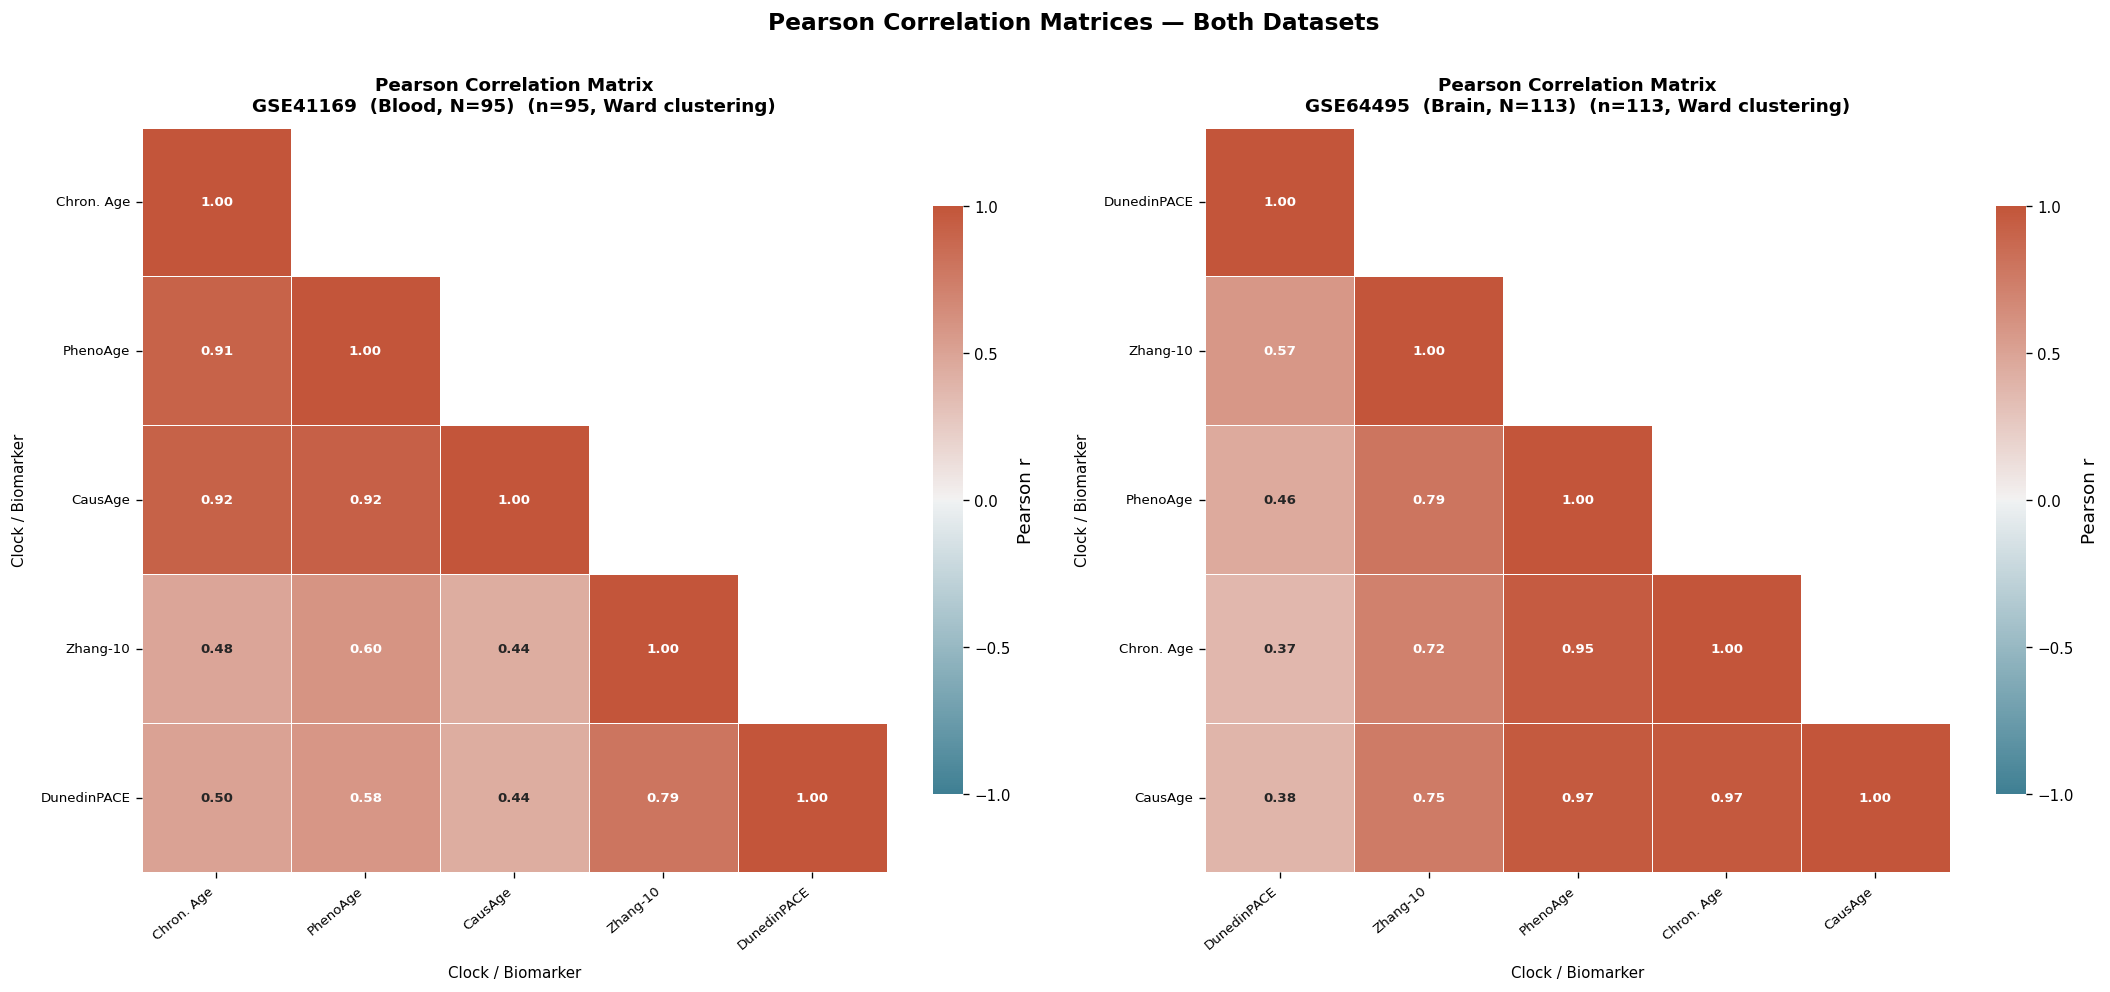

In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3  —  Correlation Matrix (both datasets)             ║
# ╚══════════════════════════════════════════════════════════════╝

def plot_correlation_matrix(results_df, clock_names, clock_labels,
                            dataset_name, ax_out=None, figsize=(9, 8)):
    """
    Lower-triangle Pearson correlation heatmap with Ward hierarchical clustering.
    Works standalone (ax_out=None) or embedded in a subplot (pass ax_out).
    """
    # ── Build working dataframe ──────────────────────────────────
    use_clocks = [c for c in clock_names
                  if c in results_df.columns
                  and results_df[c].notna().sum() > 5]
    cols = ["Chronological_Age"] + use_clocks
    df   = results_df[cols].dropna()

    rename = {"Chronological_Age": "Chron. Age"}
    rename.update({k: v for k, v in clock_labels.items() if k in df.columns})
    df = df.rename(columns=rename)

    # ── Pearson correlation ──────────────────────────────────────
    corr = df.corr(method="pearson")

    # ── Hierarchical clustering order ────────────────────────────
    dist = 1 - corr.abs()
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist.values, 0)
    lnk   = linkage(squareform(np.clip(dist.values, 0, None)), method="ward")
    order = dendrogram(lnk, no_plot=True)["leaves"]
    corr  = corr.iloc[order, :].iloc[:, order]

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    standalone = ax_out is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        ax = ax_out

    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    sns.heatmap(
        corr, mask=mask, cmap=cmap,
        vmin=-1, vmax=1,
        annot=True, fmt=".2f",
        annot_kws={"size": 8, "weight": "bold"},
        linewidths=0.5, linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.7, "label": "Pearson r",
                  "ticks": [-1, -.5, 0, .5, 1]},
        ax=ax
    )
    n_used = len(df)
    ax.set_title(
        f"Pearson Correlation Matrix\n{dataset_name}  (n={n_used}, Ward clustering)",
        fontsize=11, fontweight="bold", pad=10
    )
    ax.set_xlabel("Clock / Biomarker", fontsize=9, labelpad=8)
    ax.set_ylabel("Clock / Biomarker", fontsize=9, labelpad=8)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

    if standalone:
        plt.tight_layout()
        plt.show()

    # ── Print top pairs ──────────────────────────────────────────
    cols2 = corr.columns.tolist()
    pairs = [(cols2[i], cols2[j], corr.iloc[i, j])
             for i in range(len(cols2)) for j in range(i+1, len(cols2))]
    pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f"\n📌 {dataset_name} — Top 5 pairs (|r|):")
    for a, b, r in pairs[:5]:
        print(f"   {a:>22s}  ↔  {b:<22s}  r = {r:+.3f}")
    print(f"   Lowest: {pairs[-1][0]} ↔ {pairs[-1][1]}  r = {pairs[-1][2]:+.3f}")


# ── Side-by-side figure ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Pearson Correlation Matrices — Both Datasets",
             fontsize=14, fontweight="bold", y=1.01)

plot_correlation_matrix(results_ds1, CLOCK_NAMES, CLOCK_LABELS, DS1_NAME, ax_out=axes[0])
plot_correlation_matrix(results_ds2, CLOCK_NAMES, CLOCK_LABELS, DS2_NAME, ax_out=axes[1])

plt.tight_layout()
plt.show()

---
## 6. Age Deviation Heatmap — Both Datasets <a id='s6'></a>

**Epigenetic Age Acceleration** = predicted clock age − chronological age.  
- Positive → biologically older than expected  
- Negative → biologically younger than expected  
- For **DunedinPACE** (a rate, not an age): deviation = (pace − 1.0) × chronological age


════════════════════════════════════════════════════════════
  DATASET 1 : GSE41169  (Blood, N=95)
════════════════════════════════════════════════════════════


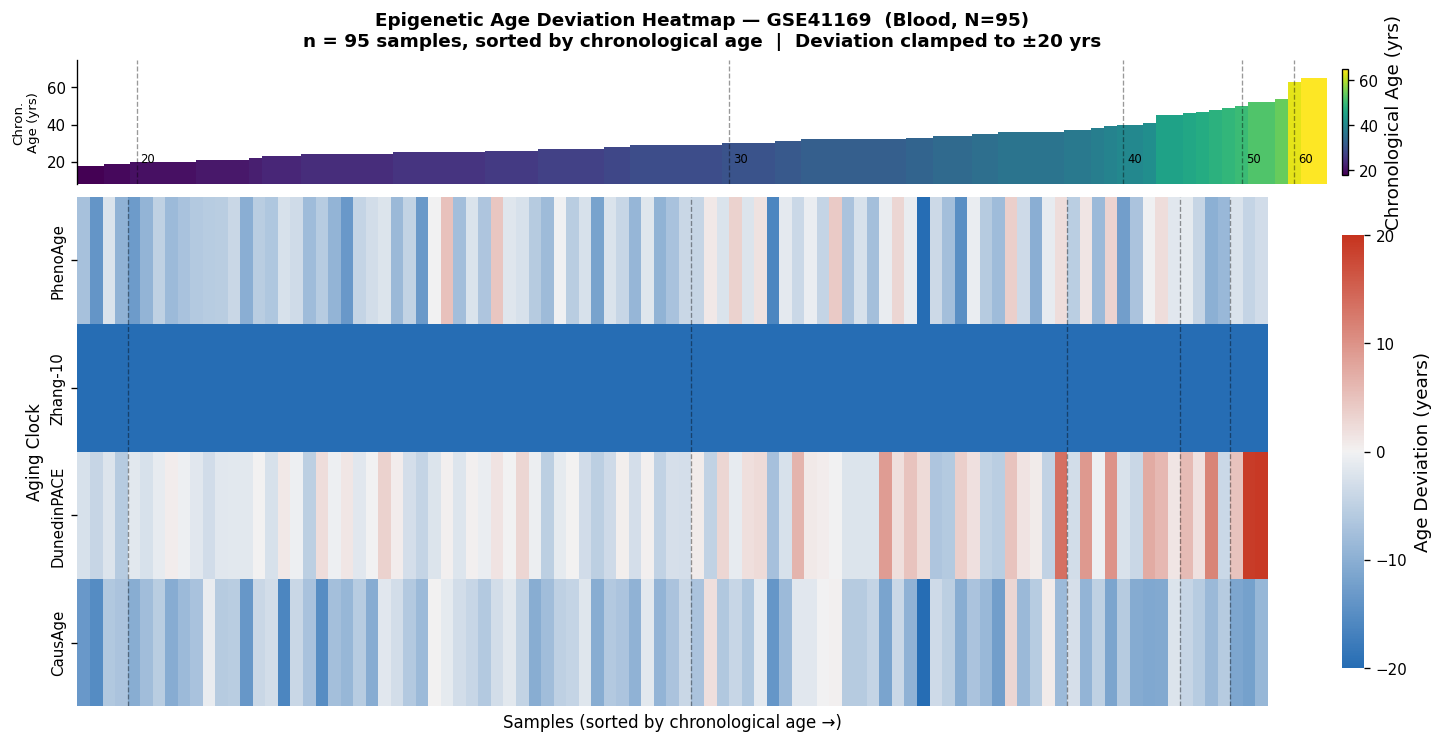


📊 Mean Age Deviations — GSE41169  (Blood, N=95):
   Clock                       Mean       SD  Status
   ────────────────────────────────────────────────────
   PhenoAge                  -4.82    5.05  ↓ decelerated
   Zhang-10                 -33.99   10.01  ↓ decelerated
   DunedinPACE               +0.24    4.86  ≈ neutral
   CausAge                   -6.64    4.37  ↓ decelerated

════════════════════════════════════════════════════════════
  DATASET 2 : GSE64495  (Brain, N=113)
════════════════════════════════════════════════════════════


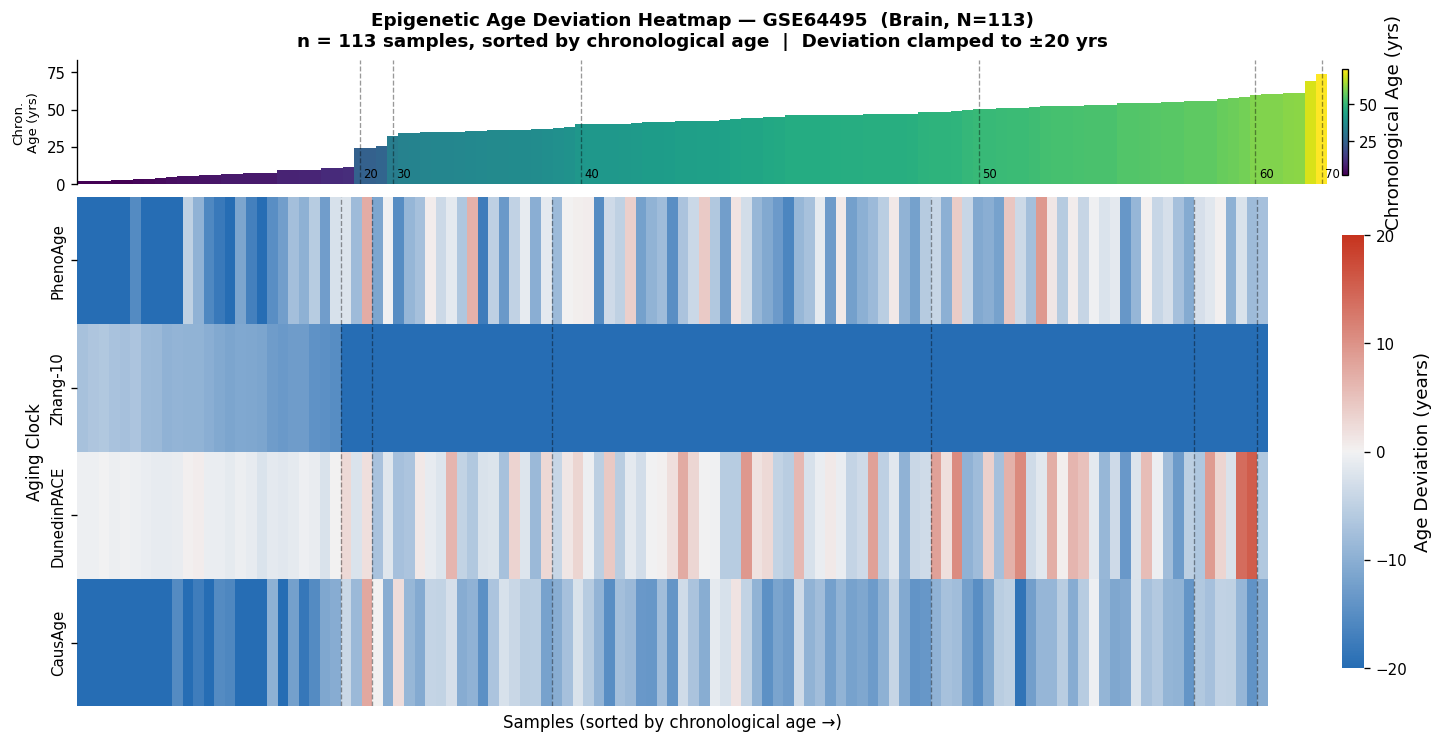


📊 Mean Age Deviations — GSE64495  (Brain, N=113):
   Clock                       Mean       SD  Status
   ────────────────────────────────────────────────────
   PhenoAge                  -8.81    9.88  ↓ decelerated
   Zhang-10                 -40.70   18.21  ↓ decelerated
   DunedinPACE               -0.74    5.17  ≈ neutral
   CausAge                  -11.03    7.43  ↓ decelerated


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4  —  Age Deviation Heatmap (both datasets)          ║
# ╚══════════════════════════════════════════════════════════════╝

def compute_deviations(results_df, clock_names, clock_labels):
    """Return a DataFrame of age deviations (clock_pred - chron_age)."""
    chron = results_df["Chronological_Age"]
    devs  = pd.DataFrame(index=results_df.index)
    for clock in clock_names:
        if clock not in results_df.columns:
            continue
        if results_df[clock].isna().all():
            continue
        lbl = clock_labels.get(clock, clock)
        if clock == "DunedinPACE":
            devs[lbl] = (results_df[clock] - 1.0) * chron
        else:
            devs[lbl] = results_df[clock] - chron
    return devs


def plot_deviation_heatmap(results_df, clock_names, clock_labels,
                           dataset_name, clamp=20, figsize=(16, 7)):
    """
    Two-panel layout:
      Top   : chronological age bar coloured by viridis
      Bottom: deviation heatmap (diverging blue-red), decade markers
    """
    devs = compute_deviations(results_df, clock_names, clock_labels)
    devs["__age"] = results_df["Chronological_Age"]
    devs = devs.dropna().sort_values("__age")
    ages = devs.pop("__age").values
    devs_cl = devs.clip(-clamp, clamp)

    n_s = len(devs)
    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 1, height_ratios=[1.1, 4.5], hspace=0.04)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    # ── Top: age bar ─────────────────────────────────────────────
    norm   = plt.Normalize(ages.min(), ages.max())
    colors = plt.cm.viridis(norm(ages))
    ax_top.bar(np.arange(n_s), ages, color=colors, width=1.0)
    ax_top.set_xlim(-0.5, n_s - 0.5)
    ax_top.set_ylim(max(0, ages.min() - 10), ages.max() + 10)
    ax_top.set_ylabel("Chron.\nAge (yrs)", fontsize=8)
    ax_top.set_xticks([])
    ax_top.spines["bottom"].set_visible(False)
    ax_top.set_title(
        f"Epigenetic Age Deviation Heatmap — {dataset_name}\n"
        f"n = {n_s} samples, sorted by chronological age  |  "
        f"Deviation clamped to ±{clamp} yrs",
        fontsize=11, fontweight="bold", pad=8
    )
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax_top, label="Chronological Age (yrs)",
                 shrink=0.85, pad=0.01, orientation="vertical")

    # ── Bottom: deviation heatmap ─────────────────────────────────
    cmap_div = sns.diverging_palette(250, 15, s=90, l=45, as_cmap=True)
    sns.heatmap(
        devs_cl.T,
        cmap=cmap_div, center=0, vmin=-clamp, vmax=clamp,
        ax=ax_bot,
        xticklabels=False, yticklabels=True,
        linewidths=0.0,
        cbar_kws={"label": "Age Deviation (years)",
                  "shrink": 0.85,
                  "ticks": [-20, -10, 0, 10, 20]}
    )
    ax_bot.set_xlabel("Samples (sorted by chronological age →)", fontsize=10)
    ax_bot.set_ylabel("Aging Clock", fontsize=10)
    plt.setp(ax_bot.get_yticklabels(), fontsize=9)

    # Decade vertical markers
    for decade in range(20, 101, 10):
        pos = int(np.searchsorted(ages, decade))
        if 0 < pos < n_s:
            ax_bot.axvline(pos, color="k", lw=0.8, ls="--", alpha=0.4)
            ax_top.axvline(pos, color="k", lw=0.8, ls="--", alpha=0.4)
            ax_top.text(pos + 0.3, ages.min(), f"{decade}",
                        fontsize=7, color="k", va="bottom")

    plt.show()

    # ── Mean deviation table ──────────────────────────────────────
    print(f"\n📊 Mean Age Deviations — {dataset_name}:")
    print(f"   {'Clock':<22s}  {'Mean':>8s}  {'SD':>7s}  Status")
    print("   " + "─" * 52)
    for col in devs.columns:
        m = devs[col].mean()
        s = devs[col].std()
        tag = "↑ accelerated" if m > 2 else ("↓ decelerated" if m < -2 else "≈ neutral")
        print(f"   {col:<22s}  {m:>+7.2f}  {s:>6.2f}  {tag}")


# ── Dataset 1 ────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  DATASET 1 :", DS1_NAME)
print("═"*60)
plot_deviation_heatmap(results_ds1, CLOCK_NAMES, CLOCK_LABELS, DS1_NAME, clamp=20)

# ── Dataset 2 ────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  DATASET 2 :", DS2_NAME)
print("═"*60)
plot_deviation_heatmap(results_ds2, CLOCK_NAMES, CLOCK_LABELS, DS2_NAME, clamp=20)

---
## 7. Predictions vs Chronological Age — Both Datasets <a id='s7'></a>

One scatter panel per clock. Each panel shows:
- Raw data scatter (coloured by generation)
- OLS regression line + bootstrap 95% CI
- Identity line y = x (perfect prediction)
- Pearson r, MAE, RMSE statistics


════════════════════════════════════════════════════════════
  DATASET 1 : GSE41169  (Blood, N=95)
════════════════════════════════════════════════════════════


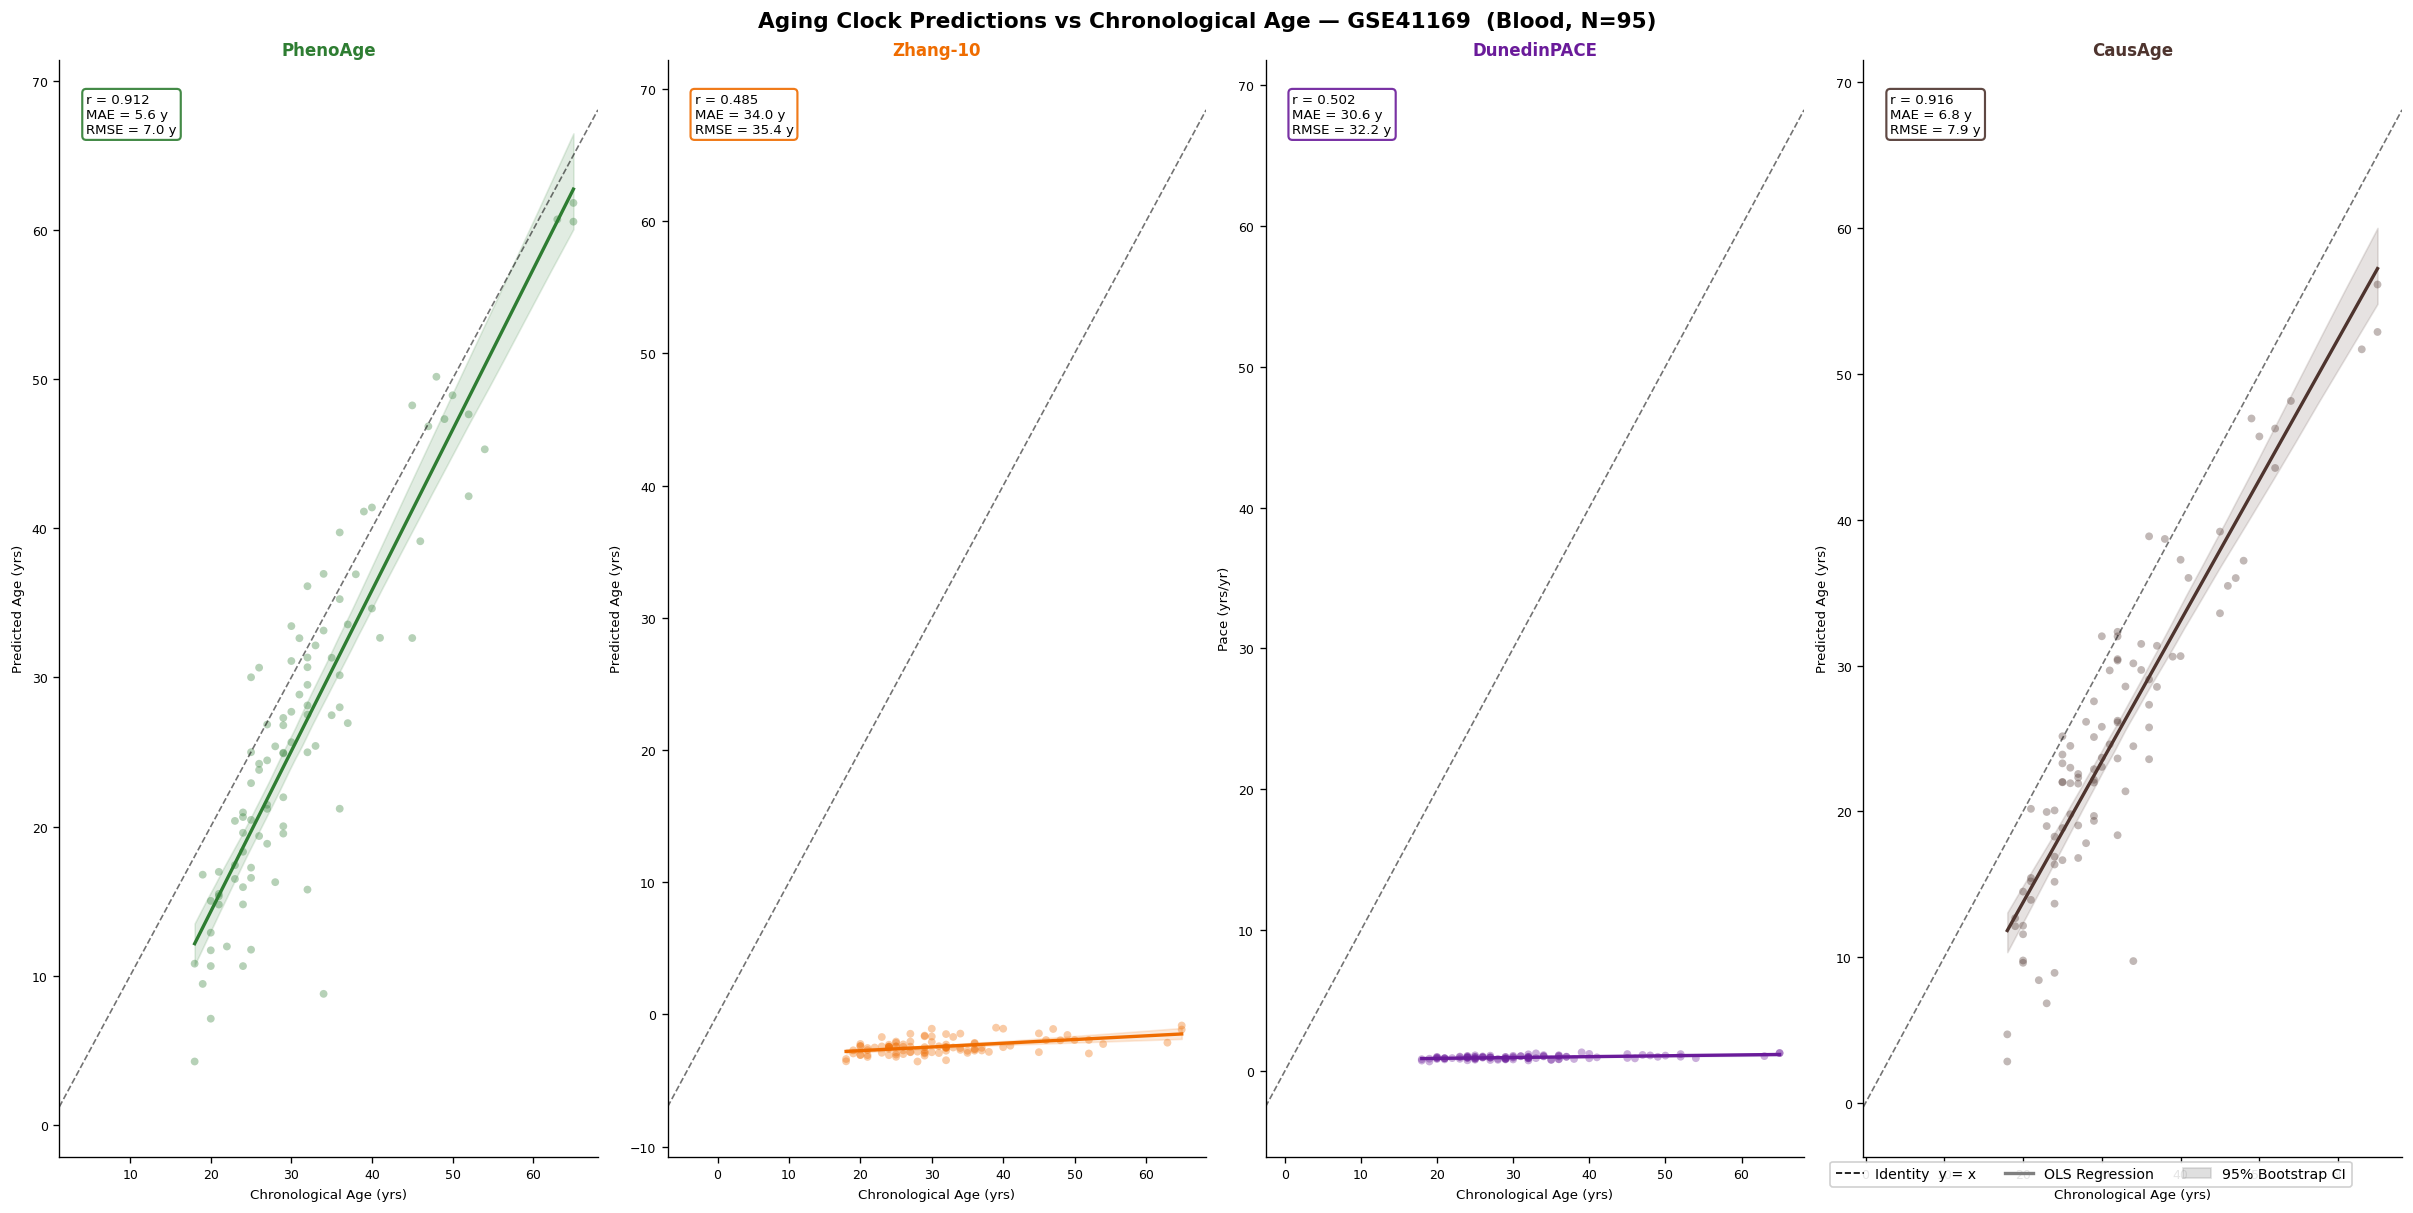


📊 Performance — GSE41169 (sorted by r):


,Clock,Pearson_r,R2,MAE_yrs,RMSE_yrs,N
0,CausAge,0.916,0.839,6.76,7.94,95
1,PhenoAge,0.912,0.831,5.57,6.96,95
2,DunedinPACE,0.502,0.252,30.58,32.23,95
3,Zhang-10,0.485,0.235,33.99,35.42,95



════════════════════════════════════════════════════════════
  DATASET 2 : GSE64495  (Brain, N=113)
════════════════════════════════════════════════════════════


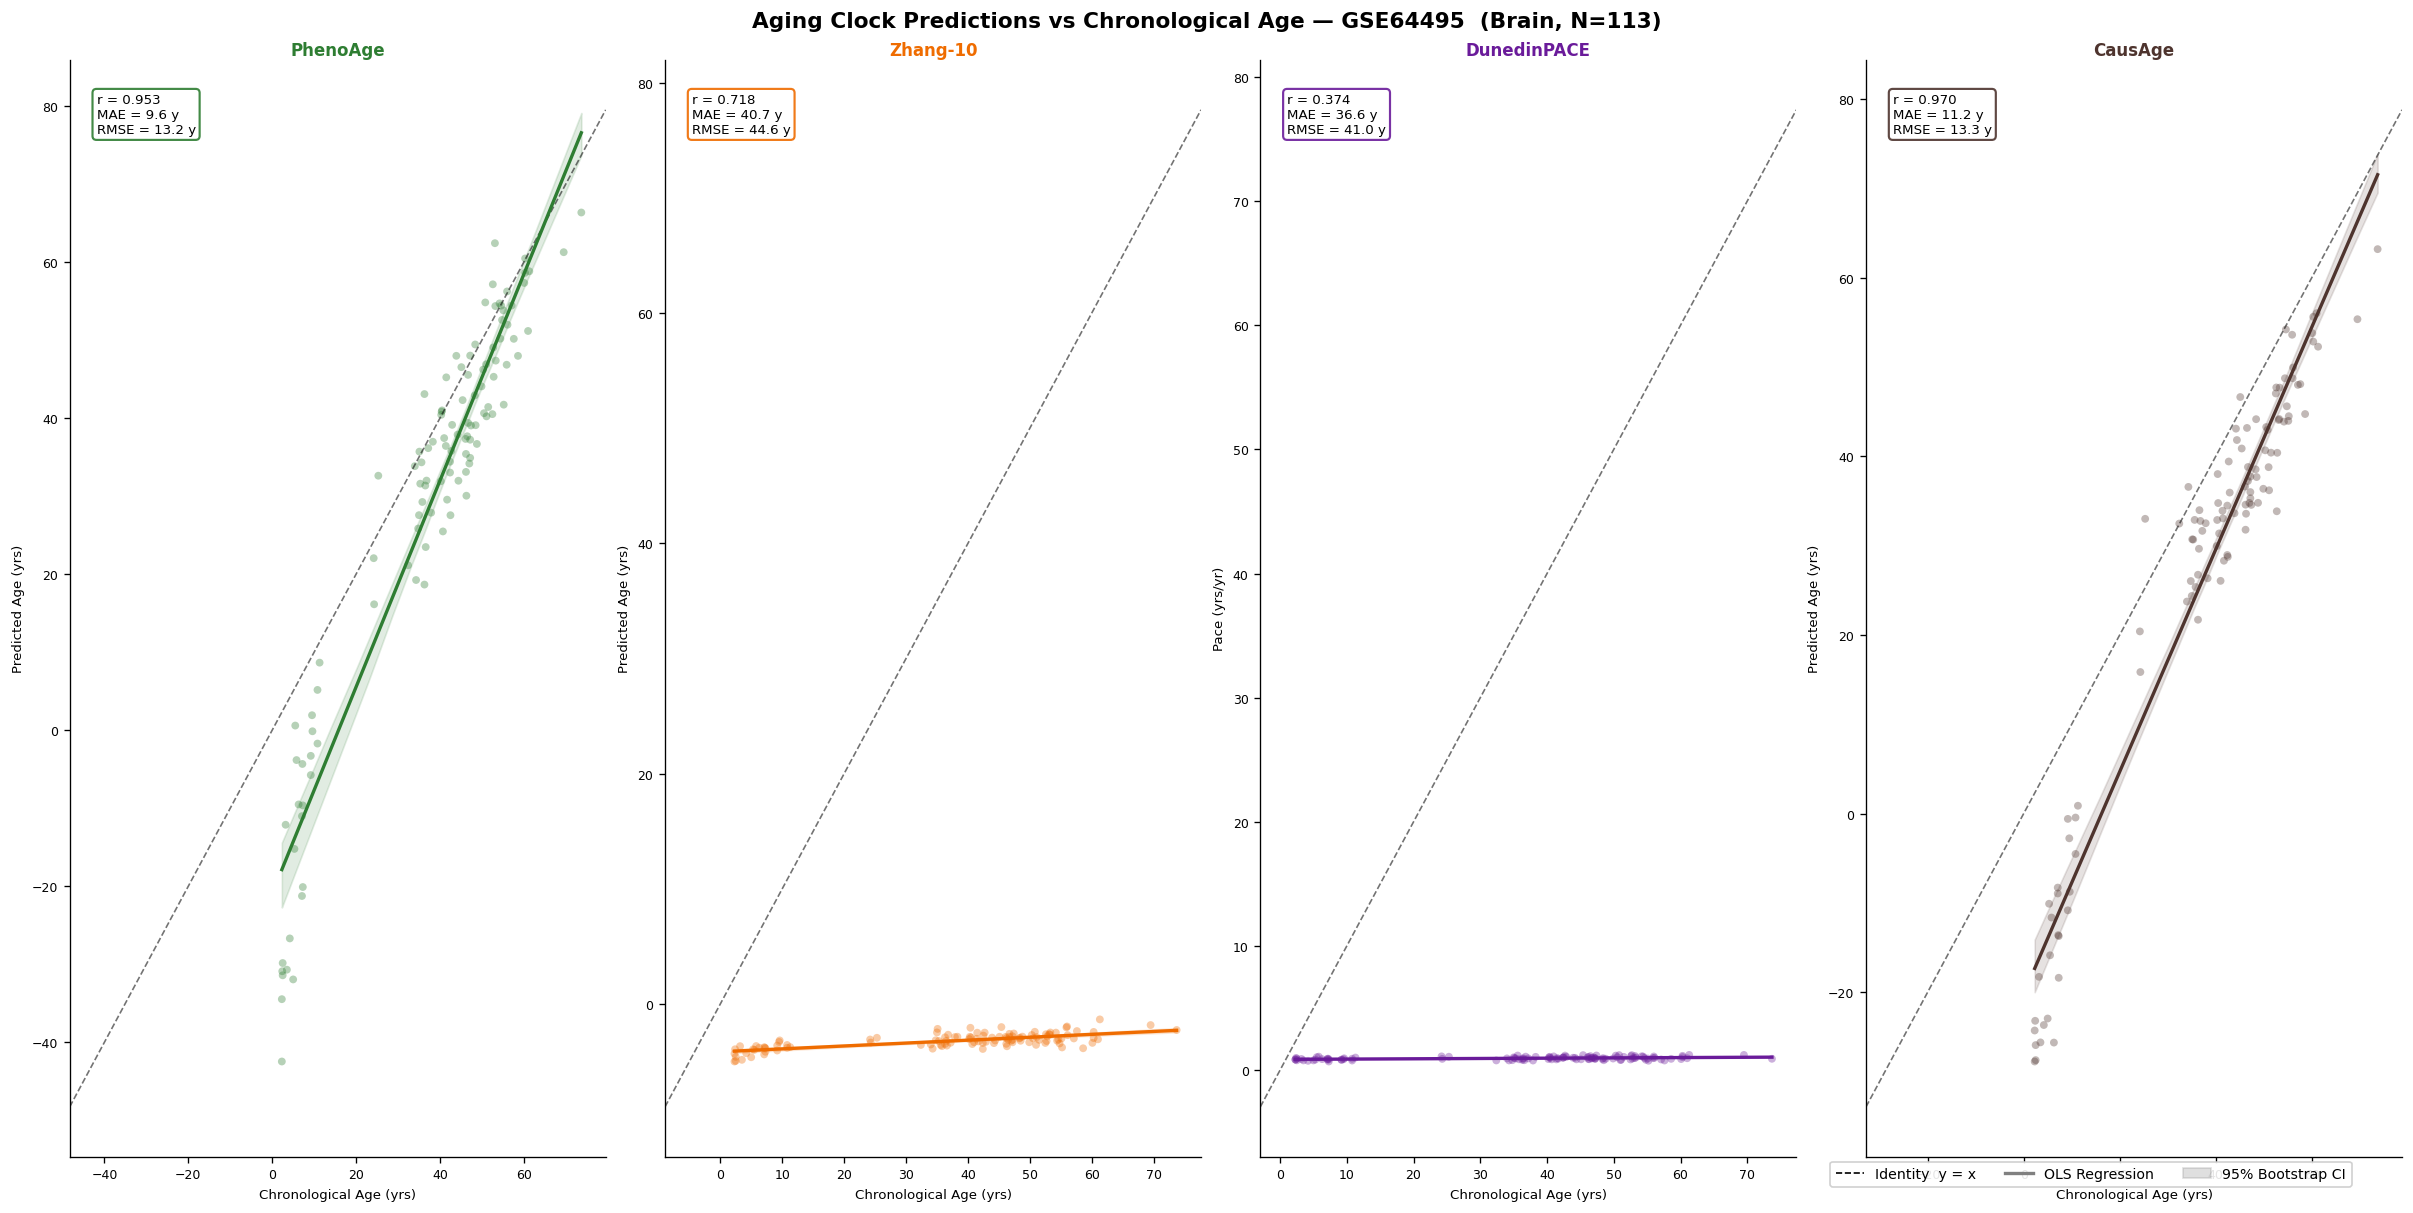


📊 Performance — GSE64495 (sorted by r):


,Clock,Pearson_r,R2,MAE_yrs,RMSE_yrs,N
0,CausAge,0.970,0.940,11.23,13.28,113
1,PhenoAge,0.953,0.909,9.64,13.21,113
2,Zhang-10,0.718,0.515,40.70,44.56,113
3,DunedinPACE,0.374,0.140,36.55,40.99,113


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5  —  Predictions vs Chronological Age               ║
# ╚══════════════════════════════════════════════════════════════╝

def plot_predictions_vs_age(results_df, clock_names, clock_labels,
                            clock_colors, dataset_name,
                            n_cols=4, figsize=(20, 10), n_boot=150):
    """
    Multi-panel scatter: predicted vs. chronological age, one panel per clock.
    Returns a stats DataFrame sorted by Pearson r.
    """
    available = [c for c in clock_names
                 if c in results_df.columns
                 and results_df[c].notna().sum() > 5]

    n_cl   = len(available)
    n_rows = (n_cl + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize,
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    fig.suptitle(
        f"Aging Clock Predictions vs Chronological Age — {dataset_name}",
        fontsize=13, fontweight="bold"
    )

    rng   = np.random.default_rng(42)
    stats = []

    for i, clock in enumerate(available):
        ax    = axes[i]
        color = clock_colors.get(clock, "#607D8B")
        label = clock_labels.get(clock, clock)

        pair = results_df[["Chronological_Age", clock]].dropna()
        x    = pair["Chronological_Age"].values.astype(float)
        y    = pair[clock].values.astype(float)

        # Axis range with padding
        pad    = (max(x.max(), y.max()) - min(x.min(), y.min())) * 0.05
        xy_min = min(x.min(), y.min()) - pad
        xy_max = max(x.max(), y.max()) + pad

        # Scatter
        ax.scatter(x, y, c=color, alpha=0.35, s=22,
                   edgecolors="none", rasterized=True, zorder=2)

        # Identity line
        ax.plot([xy_min, xy_max], [xy_min, xy_max],
                color="black", lw=1.0, ls="--", alpha=0.55,
                zorder=3, label="y = x")

        # OLS line
        coef   = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = np.polyval(coef, x_line)
        ax.plot(x_line, y_line, color=color, lw=2.0, zorder=4)

        # Bootstrap CI
        boot = np.empty((n_boot, len(x_line)))
        for b in range(n_boot):
            idx_b  = rng.integers(0, len(x), size=len(x))
            c_b    = np.polyfit(x[idx_b], y[idx_b], 1)
            boot[b] = np.polyval(c_b, x_line)
        ax.fill_between(
            x_line,
            np.percentile(boot, 2.5,  axis=0),
            np.percentile(boot, 97.5, axis=0),
            color=color, alpha=0.14, zorder=1
        )

        # Stats
        r, _  = pearsonr(x, y)
        mae   = float(np.mean(np.abs(y - x)))
        rmse  = float(np.sqrt(np.mean((y - x)**2)))
        stats.append({"Clock": label, "Pearson_r": round(r, 3),
                      "R2": round(r**2, 3),
                      "MAE_yrs": round(mae, 2),
                      "RMSE_yrs": round(rmse, 2),
                      "N": len(x)})

        # Annotation
        ax.text(
            0.05, 0.97,
            f"r = {r:.3f}\nMAE = {mae:.1f} y\nRMSE = {rmse:.1f} y",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white",
                      ec=color, alpha=0.90, lw=1.3)
        )

        ax.set_title(label, fontsize=10, fontweight="bold", color=color, pad=3)
        ax.set_xlabel("Chronological Age (yrs)", fontsize=8)
        ax.set_ylabel(
            "Pace (yrs/yr)" if clock == "DunedinPACE" else "Predicted Age (yrs)",
            fontsize=8
        )
        ax.set_xlim(xy_min, xy_max)
        ax.tick_params(labelsize=7.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Legend
    legend_els = [
        Line2D([0],[0], color="black", lw=1.0, ls="--", label="Identity  y = x"),
        Line2D([0],[0], color="gray",  lw=2.0,          label="OLS Regression"),
        mpatches.Patch(color="gray", alpha=0.25,         label="95% Bootstrap CI"),
    ]
    fig.legend(handles=legend_els, loc="lower right", ncol=3,
               fontsize=8.5, frameon=True, framealpha=0.9,
               bbox_to_anchor=(0.98, 0.01))
    plt.show()

    return pd.DataFrame(stats).sort_values("Pearson_r", ascending=False)


# ── Dataset 1 ────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  DATASET 1 :", DS1_NAME)
print("═"*60)
stats_ds1 = plot_predictions_vs_age(
    results_ds1, CLOCK_NAMES, CLOCK_LABELS, CLOCK_COLORS, DS1_NAME)
print("\n📊 Performance — GSE41169 (sorted by r):")
display(stats_ds1.reset_index(drop=True))

# ── Dataset 2 ────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  DATASET 2 :", DS2_NAME)
print("═"*60)
stats_ds2 = plot_predictions_vs_age(
    results_ds2, CLOCK_NAMES, CLOCK_LABELS, CLOCK_COLORS, DS2_NAME)
print("\n📊 Performance — GSE64495 (sorted by r):")
display(stats_ds2.reset_index(drop=True))

---
## 8. Cross-Dataset Benchmark Comparison <a id='s8'></a>

Side-by-side grouped bar charts directly comparing **Pearson r** and **MAE** across both datasets for every clock.  
Reveals which clocks are tissue-agnostic and which are blood-specific.

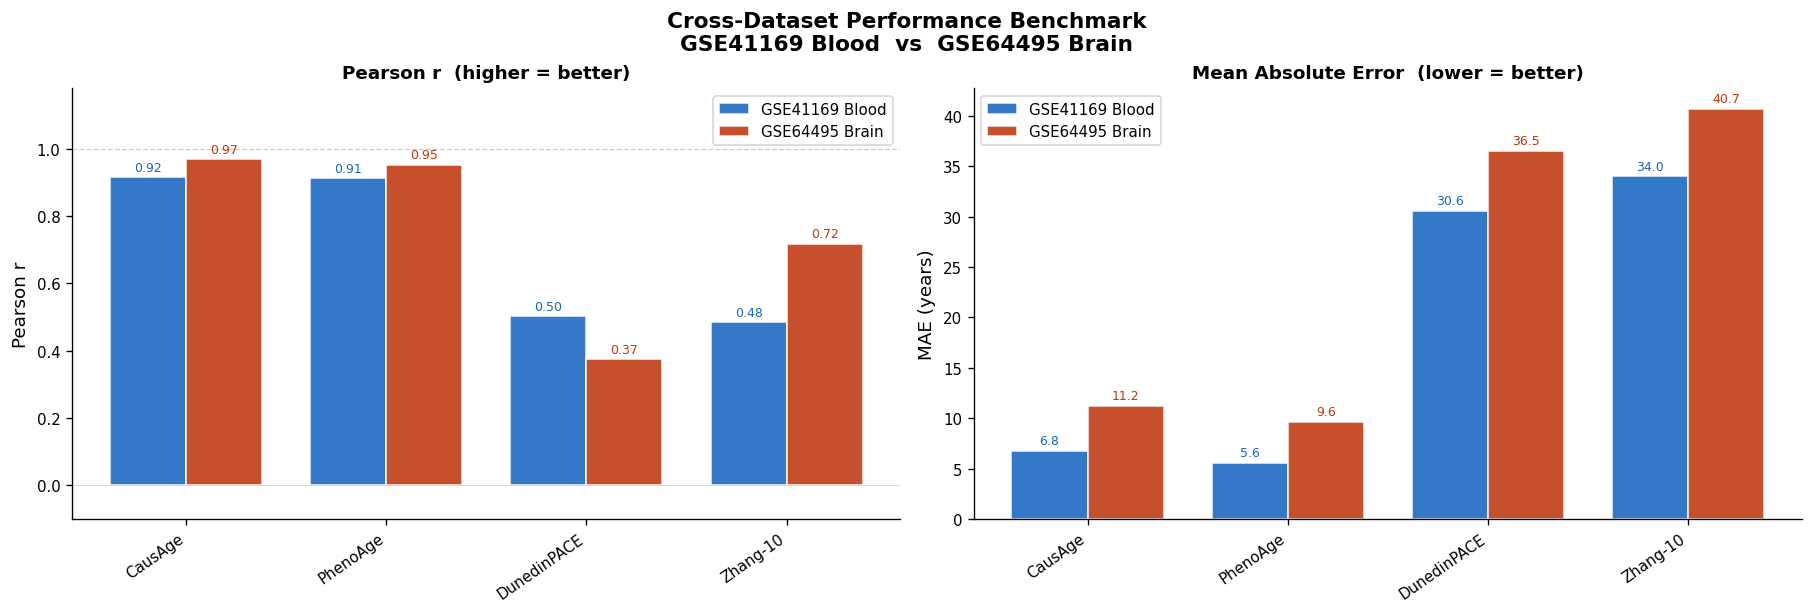


📊 Full Benchmark Table:


,Clock,r (GSE41169 Blood),r (GSE64495 Brain),MAE (GSE41169 Blood),MAE (GSE64495 Brain),RMSE (GSE41169 Blood),RMSE (GSE64495 Brain)
0,CausAge,0.916,0.970,6.76,11.23,7.94,13.28
1,PhenoAge,0.912,0.953,5.57,9.64,6.96,13.21
2,DunedinPACE,0.502,0.374,30.58,36.55,32.23,40.99
3,Zhang-10,0.485,0.718,33.99,40.70,35.42,44.56


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6  —  Cross-Dataset Benchmark                        ║
# ╚══════════════════════════════════════════════════════════════╝

def plot_benchmark(stats_a, stats_b, label_a, label_b, figsize=(15, 5)):
    """Grouped bar charts: Pearson r and MAE for both datasets side by side."""

    merged = stats_a.merge(stats_b, on="Clock",
                           suffixes=("_a", "_b"), how="inner")
    merged = merged.sort_values("Pearson_r_a", ascending=False).reset_index(drop=True)

    x  = np.arange(len(merged))
    w  = 0.38
    c1 = "#1565C0"
    c2 = "#BF360C"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(
        f"Cross-Dataset Performance Benchmark\n{label_a}  vs  {label_b}",
        fontsize=13, fontweight="bold"
    )

    # ── Pearson r ─────────────────────────────────────────────────
    b1 = ax1.bar(x - w/2, merged["Pearson_r_a"], w,
                 label=label_a, color=c1, alpha=0.87, edgecolor="white")
    b2 = ax1.bar(x + w/2, merged["Pearson_r_b"], w,
                 label=label_b, color=c2, alpha=0.87, edgecolor="white")
    ax1.bar_label(b1, fmt="%.2f", padding=2, fontsize=7.5, color=c1)
    ax1.bar_label(b2, fmt="%.2f", padding=2, fontsize=7.5, color=c2)
    ax1.set_xticks(x)
    ax1.set_xticklabels(merged["Clock"], rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("Pearson r", fontsize=11)
    ax1.set_ylim(-0.1, 1.18)
    ax1.axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.4)
    ax1.axhline(0.0, color="gray", lw=0.6, ls="-",  alpha=0.3)
    ax1.set_title("Pearson r  (higher = better)", fontsize=11, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ── MAE ───────────────────────────────────────────────────────
    b3 = ax2.bar(x - w/2, merged["MAE_yrs_a"], w,
                 label=label_a, color=c1, alpha=0.87, edgecolor="white")
    b4 = ax2.bar(x + w/2, merged["MAE_yrs_b"], w,
                 label=label_b, color=c2, alpha=0.87, edgecolor="white")
    ax2.bar_label(b3, fmt="%.1f", padding=2, fontsize=7.5, color=c1)
    ax2.bar_label(b4, fmt="%.1f", padding=2, fontsize=7.5, color=c2)
    ax2.set_xticks(x)
    ax2.set_xticklabels(merged["Clock"], rotation=35, ha="right", fontsize=9)
    ax2.set_ylabel("MAE (years)", fontsize=11)
    ax2.set_title("Mean Absolute Error  (lower = better)", fontsize=11, fontweight="bold")
    ax2.legend(fontsize=9)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    plt.show()

    # ── Full merged table ─────────────────────────────────────────
    out = merged[["Clock",
                  "Pearson_r_a", "Pearson_r_b",
                  "MAE_yrs_a",  "MAE_yrs_b",
                  "RMSE_yrs_a", "RMSE_yrs_b"]].copy()
    out.columns = [
        "Clock",
        f"r ({label_a})", f"r ({label_b})",
        f"MAE ({label_a})", f"MAE ({label_b})",
        f"RMSE ({label_a})", f"RMSE ({label_b})",
    ]
    print("\n📊 Full Benchmark Table:")
    display(out.reset_index(drop=True))


plot_benchmark(stats_ds1, stats_ds2, "GSE41169 Blood", "GSE64495 Brain")